# Omar Mohamed Elmuslimany - data analytics
# TASK 2 — Customer Segmentation Analysis

## Objective
Apply clustering algorithms to segment an e-commerce/customer dataset into distinct groups based on customer characteristics and spending behaviour, enabling targeted marketing strategies.

### Dataset used
**Customer Segmentation.csv** — the dataset supplied for this task.

### Important dataset note
This dataset contains customer-level information such as **Age, Gender, Marital Status, Graduation, Profession, Work Experience, Spending Score, Family Size and Var_1**. It does **not** contain transaction-level purchase amount, invoice dates or purchase frequency.

Therefore, the analysis uses **Spending Score + demographic/behavioural features** for clustering rather than inventing RFM Monetary/Frequency values. The existing `Segmentation` column is treated as a reference label and is **not used to create the clusters**.

In [1]:
# 1. Install/import libraries
!pip -q install kneed

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from kneed import KneeLocator

from google.colab import files

warnings = __import__("warnings")
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Upload and load the supplied dataset

Run this cell and select **Customer Segmentation.csv**. If the file is already present in the Colab session, the code will use it automatically.

In [2]:
# Find the supplied CSV or ask the user to upload it
csv_candidates = [f for f in os.listdir("/content") if f.lower().endswith(".csv")]

if "Customer Segmentation.csv" in csv_candidates:
    file_path = "/content/Customer Segmentation.csv"
elif csv_candidates:
    file_path = "/content/" + csv_candidates[0]
else:
    uploaded = files.upload()
    uploaded_csvs = [f for f in uploaded.keys() if f.lower().endswith(".csv")]
    if not uploaded_csvs:
        raise FileNotFoundError("Please upload a CSV dataset.")
    file_path = "/content/" + uploaded_csvs[0]

df = pd.read_csv(file_path)

print("File loaded:", os.path.basename(file_path))
print("Dataset shape:", df.shape)
display(df.head())

Saving Customer Segmentation.csv to Customer Segmentation.csv
File loaded: Customer Segmentation.csv
Dataset shape: (10695, 12)


,Unnamed: 0,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,0,460394,Female,No,32,Yes,Healthcare,9.0,Low,3.0,Cat_6,D
1,1,461798,Female,No,56,Yes,Artist,0.0,Low,1.0,Cat_6,A
2,2,464976,Male,Yes,75,No,Lawyer,1.0,Low,1.0,Cat_4,D
3,3,462104,Male,Yes,39,No,Entertainment,9.0,Low,2.0,Cat_3,D
4,4,464829,Male,No,22,No,Healthcare,9.0,Low,5.0,Cat_4,D


## 3. Inspect the dataset structure

We check columns, data types, missing values, duplicates and descriptive statistics before cleaning.

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Columns:
['Unnamed: 0', 'ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation']

Data types:


,dtype
Unnamed: 0,int64
ID,int64
Gender,object
Ever_Married,object
Age,int64
Graduated,object
Profession,object
Work_Experience,float64
Spending_Score,object
Family_Size,float64



Missing values:


,missing_count
Unnamed: 0,0
ID,0
Gender,0
Ever_Married,190
Age,0
Graduated,102
Profession,162
Work_Experience,1098
Spending_Score,0
Family_Size,448



Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,10695.0,NaN,NaN,NaN,5347.0,3087.524899,0.0,2673.5,5347.0,8020.5,10694.0
ID,10695.0,NaN,NaN,NaN,463468.08864,2600.966411,458982.0,461220.5,463451.0,465733.5,467974.0
Gender,10695,2,Male,5841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ever_Married,10505,2,Yes,6163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10695.0,NaN,NaN,NaN,43.511828,16.774158,18.0,30.0,41.0,53.0,89.0
Graduated,10593,2,Yes,6570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,10533,9,Artist,3318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Work_Experience,9597.0,NaN,NaN,NaN,2.619777,3.39079,0.0,0.0,1.0,4.0,14.0
Spending_Score,10695,3,Low,6494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family_Size,10247.0,NaN,NaN,NaN,2.844052,1.536427,1.0,2.0,3.0,4.0,9.0


## 4. Clean the data

Cleaning steps:
- Remove the unnecessary `Unnamed: 0` index column if present.
- Keep `ID` only as an identifier, not a clustering feature.
- Remove duplicate customer records.
- Handle missing categorical values with the most frequent category.
- Handle missing numeric values with the median.
- Convert `Spending_Score` into an ordinal numerical feature for behavioural analysis.
- Keep the original `Segmentation` column only as a reference for later comparison.

In [4]:
data = df.copy()

# Remove exported dataframe index column
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

# Remove duplicate rows
before = len(data)
data = data.drop_duplicates()
after = len(data)

print(f"Rows before duplicate removal: {before:,}")
print(f"Rows after duplicate removal:  {after:,}")
print(f"Duplicates removed:            {before - after:,}")

# Create an ordinal version of Spending Score
spending_map = {
    "Low": 1,
    "Average": 2,
    "High": 3
}

data["Spending_Score_Ordinal"] = data["Spending_Score"].map(spending_map)

print("\nSpending Score mapping:")
print(spending_map)

display(data.head())

Rows before duplicate removal: 10,695
Rows after duplicate removal:  10,657
Duplicates removed:            38

Spending Score mapping:
{'Low': 1, 'Average': 2, 'High': 3}


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Spending_Score_Ordinal
0,460394,Female,No,32,Yes,Healthcare,9.0,Low,3.0,Cat_6,D,1
1,461798,Female,No,56,Yes,Artist,0.0,Low,1.0,Cat_6,A,1
2,464976,Male,Yes,75,No,Lawyer,1.0,Low,1.0,Cat_4,D,1
3,462104,Male,Yes,39,No,Entertainment,9.0,Low,2.0,Cat_3,D,1
4,464829,Male,No,22,No,Healthcare,9.0,Low,5.0,Cat_4,D,1


## 5. Descriptive statistics and customer behaviour

Because this is a customer-level segmentation dataset rather than transaction-level retail data, we use the available behavioural proxy **Spending Score** and customer characteristics.

We calculate:
- Average age
- Average work experience
- Average family size
- Average spending-score level
- Distribution of spending score

In [5]:
print(f"Average age: {data['Age'].mean():.2f} years")
print(f"Average work experience: {data['Work_Experience'].mean():.2f} years")
print(f"Average family size: {data['Family_Size'].mean():.2f}")
print(f"Average spending-score level: {data['Spending_Score_Ordinal'].mean():.2f} / 3")

print("\nSpending Score distribution:")
display(data["Spending_Score"].value_counts(dropna=False).to_frame("Customers"))

print("\nCategorical feature distributions:")
for col in ["Gender", "Ever_Married", "Graduated", "Profession"]:
    print(f"\n{col}:")
    display(data[col].value_counts(dropna=False).head(10).to_frame("Customers"))

Average age: 43.54 years
Average work experience: 2.62 years
Average family size: 2.84
Average spending-score level: 1.54 / 3

Spending Score distribution:


,Customers
Spending_Score,
Low,6465
Average,2593
High,1599



Categorical feature distributions:

Gender:


,Customers
Gender,
Male,5821
Female,4836



Ever_Married:


,Customers
Ever_Married,
Yes,6145
No,4323
NaN,189



Graduated:


,Customers
Graduated,
Yes,6550
No,4007
NaN,100



Profession:


,Customers
Profession,
Artist,3309
Healthcare,1740
Entertainment,1247
Engineer,931
Doctor,926
Lawyer,843
Executive,772
Marketing,401
Homemaker,326


## 6. Feature selection

The clustering features are selected from the information actually available in the supplied dataset.

### Numeric/behavioural features
- Age
- Work Experience
- Family Size
- Spending Score (ordinal)

### Categorical features
- Gender
- Ever Married
- Graduated
- Profession
- Var_1

### Excluded
- `ID`: identifier only.
- `Segmentation`: existing segment label; using it during clustering would cause data leakage.

In [6]:
numeric_features = [
    "Age",
    "Work_Experience",
    "Family_Size",
    "Spending_Score_Ordinal"
]

categorical_features = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Var_1"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_Ordinal']
Categorical features: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Var_1']


## 7. Data normalisation / standardisation

K-Means is distance-based, so numerical variables need to be on comparable scales. Numeric variables are imputed with the median and standardised with `StandardScaler`. Categorical variables are imputed with the most frequent value and converted to one-hot encoded features.

In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X = preprocessor.fit_transform(data[numeric_features + categorical_features])

print("Prepared clustering matrix shape:", X.shape)

Prepared clustering matrix shape: (10657, 26)


## 8. K-Means clustering




Suggested K from automatic elbow detection: 4


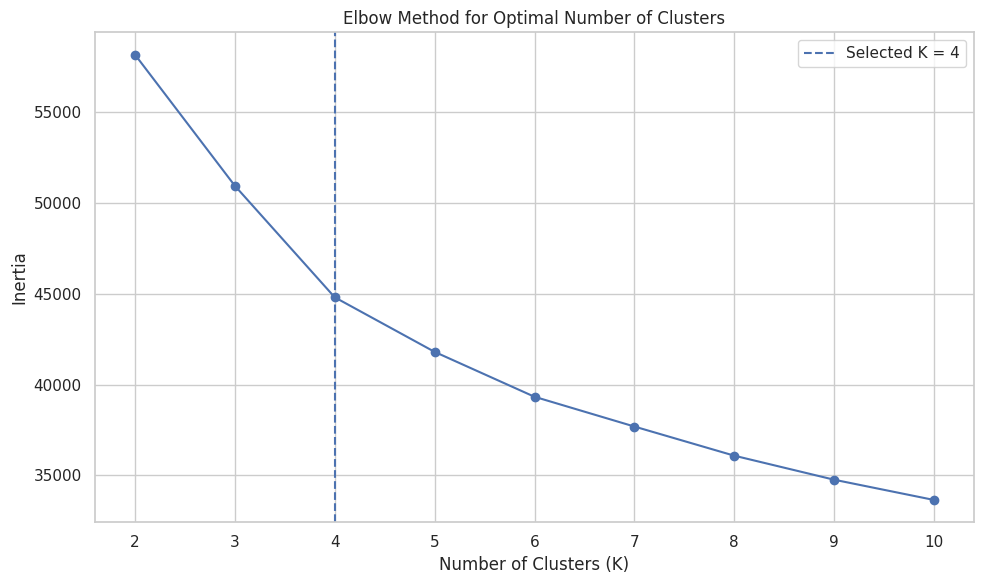

In [8]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

knee = KneeLocator(
    list(k_values),
    inertias,
    curve="convex",
    direction="decreasing"
)

suggested_k = knee.knee if knee.knee is not None else 4

print("Suggested K from automatic elbow detection:", suggested_k)

plt.figure(figsize=(10, 6))
plt.plot(list(k_values), inertias, marker="o")
plt.axvline(
    suggested_k,
    linestyle="--",
    label=f"Selected K = {suggested_k}"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

## 9. Confirm K with silhouette scores

The silhouette score provides a second diagnostic for cluster separation. We compare K values and use the Elbow Method as the primary selection criterion required by the task.

In [9]:
silhouette_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_results.append(score)

validation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette_Score": silhouette_results
})

display(validation)

best_silhouette_k = int(
    validation.loc[validation["Silhouette_Score"].idxmax(), "K"]
)

print(f"Highest silhouette score occurs at K = {best_silhouette_k}")
print(f"Elbow-selected K = {suggested_k}")

,K,Inertia,Silhouette_Score
0,2,58174.745336,0.186677
1,3,50952.612734,0.194222
2,4,44809.559403,0.184030
3,5,41805.115354,0.167000
4,6,39332.118042,0.159650
5,7,37693.255257,0.160012
6,8,36088.130974,0.154027
7,9,34764.599939,0.152411
8,10,33648.896450,0.150711


Highest silhouette score occurs at K = 3
Elbow-selected K = 4


## 10. Apply K-Means clustering

We now train the final K-Means model using the K selected from the Elbow Method.

In [10]:
optimal_k = int(suggested_k)

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(X)

final_silhouette = silhouette_score(X, data["Cluster"])

print(f"Final number of clusters: {optimal_k}")
print(f"Final silhouette score: {final_silhouette:.3f}")

print("\nCustomers per cluster:")
display(data["Cluster"].value_counts().sort_index().to_frame("Customer_Count"))

Final number of clusters: 4
Final silhouette score: 0.184

Customers per cluster:


,Customer_Count
Cluster,
0,3638
1,1845
2,2786
3,2388


## 11. Visualise the clusters — Age vs Work Experience

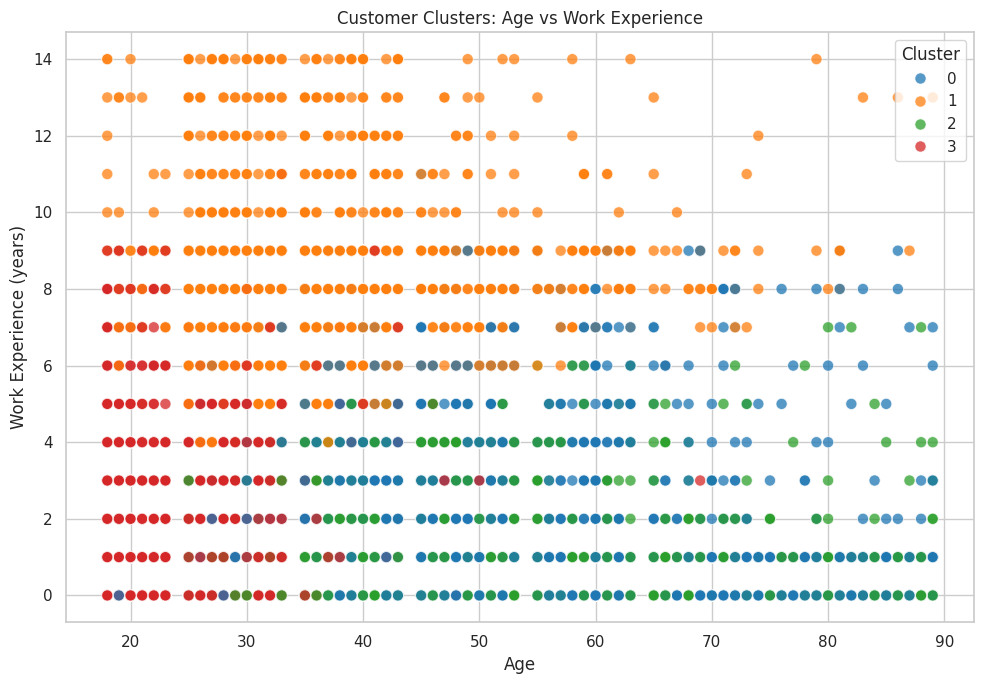

In [11]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="Age",
    y="Work_Experience",
    hue="Cluster",
    palette="tab10",
    s=65,
    alpha=0.75
)

plt.title("Customer Clusters: Age vs Work Experience")
plt.xlabel("Age")
plt.ylabel("Work Experience (years)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 12. Visualise the clusters — Age vs Family Size

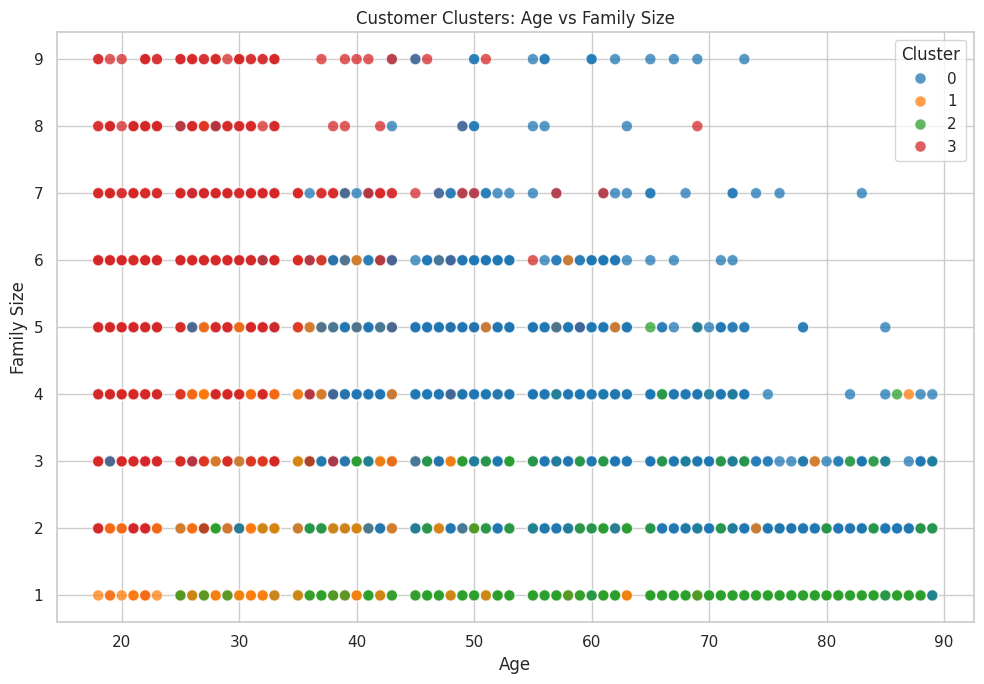

In [12]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="Age",
    y="Family_Size",
    hue="Cluster",
    palette="tab10",
    s=65,
    alpha=0.75
)

plt.title("Customer Clusters: Age vs Family Size")
plt.xlabel("Age")
plt.ylabel("Family Size")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 13. Visualise the clusters — Age vs Spending Score

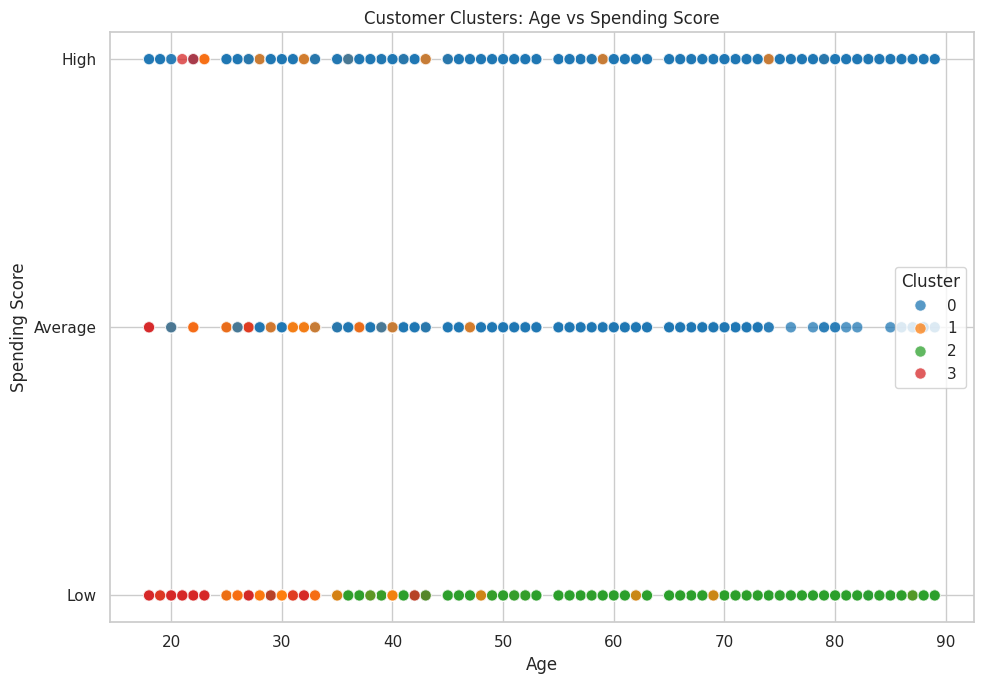

In [13]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="Age",
    y="Spending_Score_Ordinal",
    hue="Cluster",
    palette="tab10",
    s=65,
    alpha=0.75
)

plt.yticks([1, 2, 3], ["Low", "Average", "High"])
plt.title("Customer Clusters: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 14. Profile each cluster

For each cluster we calculate:
- Number of customers
- Percentage of customers
- Mean age
- Mean work experience
- Mean family size
- Mean spending-score level
- Most common gender
- Most common marital status
- Most common graduation status
- Most common profession

In [14]:
# Numeric cluster profile
numeric_profile = data.groupby("Cluster")[numeric_features].mean()

numeric_profile["Customer_Count"] = data.groupby("Cluster").size()
numeric_profile["Customer_Percentage"] = (
    numeric_profile["Customer_Count"] / len(data) * 100
)

# Most common category in each cluster
def mode_value(series):
    mode = series.dropna().mode()
    return mode.iloc[0] if len(mode) else "Unknown"

for col in categorical_features:
    numeric_profile[f"Top_{col}"] = data.groupby("Cluster")[col].agg(mode_value)

cluster_profile = numeric_profile.copy()

cluster_profile = cluster_profile[
    [
        "Customer_Count",
        "Customer_Percentage",
        "Age",
        "Work_Experience",
        "Family_Size",
        "Spending_Score_Ordinal",
        "Top_Gender",
        "Top_Ever_Married",
        "Top_Graduated",
        "Top_Profession",
        "Top_Var_1"
    ]
].round(2)

display(cluster_profile)

,Customer_Count,Customer_Percentage,Age,Work_Experience,Family_Size,Spending_Score_Ordinal,Top_Gender,Top_Ever_Married,Top_Graduated,Top_Profession,Top_Var_1
Cluster,,,,,,,,,,,
0,3638,34.14,53.17,1.32,3.08,2.41,Male,Yes,Yes,Artist,Cat_6
1,1845,17.31,37.23,8.53,2.31,1.33,Female,No,Yes,Artist,Cat_6
2,2786,26.14,49.41,0.93,1.62,1.00,Male,Yes,Yes,Artist,Cat_6
3,2388,22.41,26.90,1.39,4.27,1.02,Male,No,No,Healthcare,Cat_6


## 15. Interpret the spending behaviour of each cluster

We classify clusters into practical marketing segments based on their average spending score and customer profile. The rules are data-driven from the cluster averages rather than using the existing `Segmentation` label.

In [15]:
# Thresholds based on cluster-level spending score
spending_mean = cluster_profile["Spending_Score_Ordinal"].mean()
age_mean = cluster_profile["Age"].mean()

def assign_segment(row):
    spending = row["Spending_Score_Ordinal"]

    if spending >= 2.5:
        return "High-Spending Customers"
    elif spending < 1.5:
        return "Low-Spending / Price-Sensitive"
    elif row["Age"] < age_mean and spending >= spending_mean:
        return "Young Growth Customers"
    else:
        return "Average-Spending Customers"

cluster_profile["Segment"] = cluster_profile.apply(assign_segment, axis=1)

recommendations = {
    "High-Spending Customers":
        "Use VIP rewards, premium products, personalised recommendations, exclusive early access and loyalty benefits.",
    "Low-Spending / Price-Sensitive":
        "Use value bundles, discounts, free-shipping thresholds and affordable product recommendations.",
    "Young Growth Customers":
        "Use social/digital campaigns, personalised recommendations, bundles and incentives to increase repeat spending.",
    "Average-Spending Customers":
        "Use cross-selling, loyalty points, personalised offers and targeted promotions to increase basket value."
}

cluster_profile["Marketing_Action"] = cluster_profile["Segment"].map(recommendations)

display(
    cluster_profile[
        [
            "Segment",
            "Customer_Count",
            "Customer_Percentage",
            "Age",
            "Work_Experience",
            "Family_Size",
            "Spending_Score_Ordinal",
            "Top_Gender",
            "Top_Ever_Married",
            "Top_Graduated",
            "Top_Profession",
            "Marketing_Action"
        ]
    ]
)

,Segment,Customer_Count,Customer_Percentage,Age,Work_Experience,Family_Size,Spending_Score_Ordinal,Top_Gender,Top_Ever_Married,Top_Graduated,Top_Profession,Marketing_Action
Cluster,,,,,,,,,,,,
0,Average-Spending Customers,3638,34.14,53.17,1.32,3.08,2.41,Male,Yes,Yes,Artist,"Use cross-selling, loyalty points, personalise..."
1,Low-Spending / Price-Sensitive,1845,17.31,37.23,8.53,2.31,1.33,Female,No,Yes,Artist,"Use value bundles, discounts, free-shipping th..."
2,Low-Spending / Price-Sensitive,2786,26.14,49.41,0.93,1.62,1.00,Male,Yes,Yes,Artist,"Use value bundles, discounts, free-shipping th..."
3,Low-Spending / Price-Sensitive,2388,22.41,26.90,1.39,4.27,1.02,Male,No,No,Healthcare,"Use value bundles, discounts, free-shipping th..."


## 16. Bar chart — number of customers per cluster

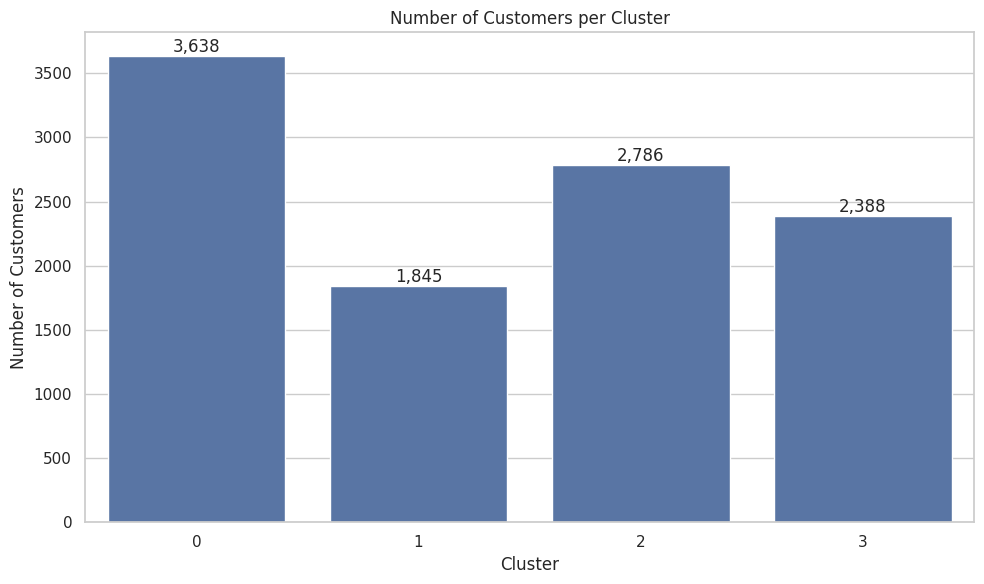

In [16]:
cluster_counts = data["Cluster"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values,
    errorbar=None
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

for i, value in enumerate(cluster_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 17. Compare discovered clusters with the original Segmentation column

The original dataset contains a `Segmentation` field (A/B/C/D). It is **not used in K-Means**, but we can compare it afterward to understand how the unsupervised clusters relate to the supplied labels.

This is an evaluation step, not part of the clustering input.

In [17]:
if "Segmentation" in data.columns:
    comparison = pd.crosstab(
        data["Cluster"],
        data["Segmentation"],
        normalize="index"
    ).round(3)

    print("Cluster vs original Segmentation (row percentages):")
    display(comparison)

    ari = adjusted_rand_score(
        data["Segmentation"],
        data["Cluster"]
    )

    print(f"Adjusted Rand Index: {ari:.3f}")
else:
    print("No original Segmentation column found.")

Cluster vs original Segmentation (row percentages):


Segmentation,A,B,C,D
Cluster,,,,
0,0.214,0.289,0.381,0.116
1,0.311,0.203,0.176,0.311
2,0.358,0.255,0.157,0.230
3,0.195,0.111,0.120,0.574


Adjusted Rand Index: 0.067


## 18. Final customer-level output

Each customer now has an assigned cluster and an interpretable segment name.

In [18]:
segment_map = cluster_profile["Segment"].to_dict()

data["Segment"] = data["Cluster"].map(segment_map)

output_columns = [
    col for col in [
        "ID", "Gender", "Ever_Married", "Age", "Graduated",
        "Profession", "Work_Experience", "Spending_Score",
        "Family_Size", "Var_1", "Segmentation",
        "Cluster", "Segment"
    ]
    if col in data.columns
]

customer_segments = data[output_columns].copy()

display(customer_segments.head(20))

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Cluster,Segment
0,460394,Female,No,32,Yes,Healthcare,9.0,Low,3.0,Cat_6,D,1,Low-Spending / Price-Sensitive
1,461798,Female,No,56,Yes,Artist,0.0,Low,1.0,Cat_6,A,2,Low-Spending / Price-Sensitive
2,464976,Male,Yes,75,No,Lawyer,1.0,Low,1.0,Cat_4,D,2,Low-Spending / Price-Sensitive
3,462104,Male,Yes,39,No,Entertainment,9.0,Low,2.0,Cat_3,D,1,Low-Spending / Price-Sensitive
4,464829,Male,No,22,No,Healthcare,9.0,Low,5.0,Cat_4,D,3,Low-Spending / Price-Sensitive
5,464634,Female,No,32,Yes,Engineer,NaN,Low,9.0,Cat_4,D,3,Low-Spending / Price-Sensitive
6,467670,Male,No,25,No,Engineer,NaN,Low,3.0,Cat_6,A,3,Low-Spending / Price-Sensitive
7,462073,Female,No,36,Yes,Artist,6.0,Low,1.0,Cat_6,C,1,Low-Spending / Price-Sensitive
8,463611,Male,No,62,Yes,Artist,0.0,Low,NaN,Cat_6,A,2,Low-Spending / Price-Sensitive
9,460962,Male,Yes,55,Yes,Executive,9.0,High,4.0,Cat_6,C,0,Average-Spending Customers


## 19. Export the results

Two CSV files are created:
1. `customer_segments.csv` — every customer with their K-Means cluster and segment.
2. `cluster_profile.csv` — summary statistics and marketing recommendations for each cluster.

In [19]:
customer_segments.to_csv("customer_segments.csv", index=False)
cluster_profile.to_csv("cluster_profile.csv")

print("Files created successfully:")
print("1. customer_segments.csv")
print("2. cluster_profile.csv")

# Download the main result
files.download("customer_segments.csv")

Files created successfully:
1. customer_segments.csv
2. cluster_profile.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Conclusion

This customer segmentation analysis used the supplied **Customer Segmentation.csv** dataset and completed the required clustering workflow:

1. Loaded and inspected the dataset.
2. Handled duplicates and missing values.
3. Calculated descriptive statistics.
4. Selected behavioural and customer-profile features.
5. Converted Spending Score to an ordinal numerical feature.
6. Standardised numerical variables using `StandardScaler`.
7. One-hot encoded categorical variables.
8. Used the **Elbow Method** to select the number of K-Means clusters.
9. Applied **K-Means clustering**.
10. Validated the result with a silhouette score.
11. Created three cluster visualisations.
12. Calculated the number and percentage of customers in each cluster.
13. Profiled each cluster using mean values and dominant categories.
14. Recommended marketing actions for every segment.
15. Compared clusters with the original A/B/C/D segmentation labels without using those labels for training.
16. Exported the final customer-level segmentation results.

### Note for the report
This dataset is not transaction-level retail data, so true **RFM Recency, Frequency and Monetary** analysis cannot be calculated from it. The analysis therefore uses the available **Spending Score and customer characteristics** rather than creating unsupported purchase metrics.